<a href="https://colab.research.google.com/github/lxlyp438/PyTorch_Deep_Learning_course/blob/main/04_00_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow_datasets as tfds

# List available datasets to confirm 'food_101' is there (optional, but good for verification)
# print(tfds.list_builders())

# Load the food_101 dataset. as_supervised=True returns (image, label) pairs.
# with_info=True returns a tfds.DatasetInfo object containing metadata.
ds, info = tfds.load('food_101', split='train', with_info=True, as_supervised=True)

# Print information about the dataset
print(info)

The `food_101` dataset is now loaded. The `info` object contains details about the dataset, including the number of examples, features, and label names. Let's inspect a few examples from the dataset.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Take a few examples from the dataset
fig = plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds.take(9)):
    ax = fig.add_subplot(3, 3, i + 1, xticks=[], yticks=[])
    ax.imshow(image.numpy())
    ax.set_title(info.features['label'].int2str(label.numpy()))
plt.tight_layout()
plt.show()

## Implement using torchvision

In [ ]:
import torchvision
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

# Define transformations for the images
# Common transformations include resizing, converting to tensor, and normalization.
# For a basic display, we'll just convert to tensor.
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size
    transforms.ToTensor()          # Convert images to PyTorch tensors
])

# Load the Food101 dataset
# root: directory where the datasets are stored/downloaded
# split: 'train' or 'test'
# download: True to download the dataset if it's not present
# transform: transformations to apply to the images

# Note: Food101 in torchvision requires a `split` parameter, not `train` or `test` directly in `load` like TFDS
# The split is handled by the `Food101` class itself. Let's load the training split.

try:
    train_dataset = torchvision.datasets.Food101(root='./data', split='train', download=True, transform=transform)
    test_dataset = torchvision.datasets.Food101(root='./data', split='test', download=True, transform=transform)
    print("Food101 dataset loaded successfully with torchvision!")
    print(f"Number of training samples: {len(train_dataset)}")
    print(f"Number of test samples: {len(test_dataset)}")
except Exception as e:
    print(f"Error loading Food101 dataset with torchvision: {e}")
    print("Please ensure you have an internet connection and sufficient disk space.")

100%|██████████| 5.00G/5.00G [02:43<00:00, 30.6MB/s]


Food101 dataset loaded successfully with torchvision!
Number of training samples: 75750
Number of test samples: 25250


Let's visualize a few examples from the `torchvision` loaded dataset.

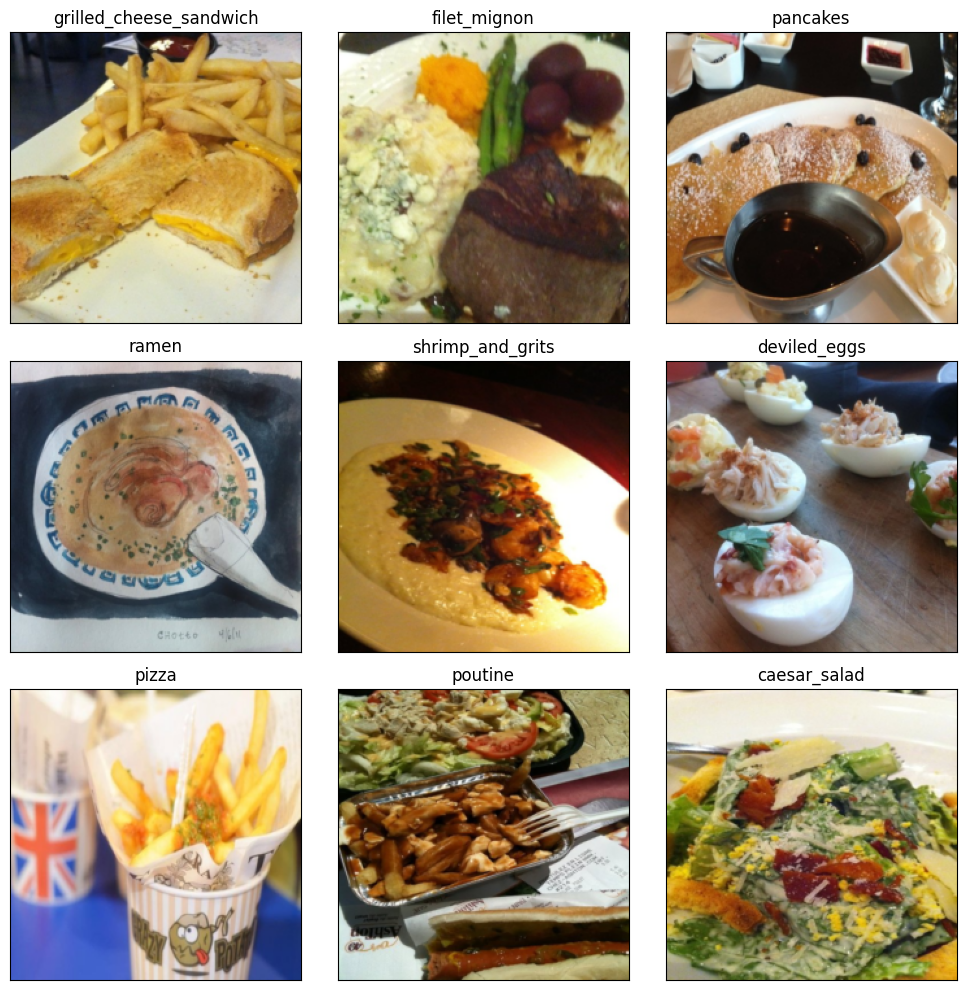

In [ ]:
# Get the class names (labels) from the dataset
class_names = train_dataset.classes

# Display a few images
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    # Get a random image and its label
    idx = torch.randint(0, len(train_dataset), (1,)).item()
    img, label = train_dataset[idx]

    ax = fig.add_subplot(3, 3, i + 1, xticks=[], yticks=[])
    # torchvision.transforms.ToTensor() puts the channel dimension first (C, H, W)
    # Matplotlib expects (H, W, C) for image display, so we permute the dimensions
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[label])
plt.tight_layout()
plt.show()

In [ ]:
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

# Task
The task is to create a function `create_food101_subset` that takes the full Food-101 training and testing datasets (as loaded by torchvision), a list of target classes, a sampling percentage, and an output directory. This function should:
1. Filter the datasets to include only the specified target classes.
2. Randomly sample the given percentage of images for each target class.
3. Organize the sampled images into a new directory structure `base_output_dir/{train|test}/class_name/`.
4. Compress the entire `base_output_dir` into a zip file named `base_output_dir.zip` within the 'data' folder.

After defining this function, it should be called with `target_classes = ['steak', 'pizza', 'dumplings', 'pho', 'poutine']`, `percentage = 0.30`, and an appropriate `base_output_dir`.

This modularized process will result in a smaller, focused dataset subset and a compressed archive of it.


## Define `create_food101_subset` Function

### Subtask:
Create a Python function, `create_food101_subset`, that encapsulates the logic for creating a subset of the Food-101 dataset. This function will take parameters such as the full `train_dataset`, `test_dataset`, a list of `target_classes`, a `percentage` for sampling, and a `base_output_dir`.


**Reasoning**:
The subtask requires defining a Python function with specific parameters and a docstring. This step directly addresses that requirement.



In [ ]:
def create_food101_subset(train_dataset, test_dataset, target_classes, percentage, base_output_dir):
    """
    Creates a subset of the Food-101 dataset based on target classes and a sampling percentage.

    Args:
        train_dataset (torchvision.datasets.Food101): The full Food-101 training dataset.
        test_dataset (torchvision.datasets.Food101): The full Food-101 test dataset.
        target_classes (list): A list of class names (strings) to include in the subset.
        percentage (float): The percentage of samples to take from each target class (0.0 to 1.0).
        base_output_dir (str): The base directory to save the subset data.

    Returns:
        tuple: A tuple containing the subsetted training and test datasets.
    """
    # Function implementation will be added in subsequent steps
    pass

## Implement Subset Creation Logic

### Subtask:
Filter the datasets, randomly sample images, and save them to a new directory structure.


**Reasoning**:
The subtask requires implementing the core logic within the `create_food101_subset` function, including importing necessary libraries, defining a helper function, and handling directory creation, image grouping, sampling, conversion, and saving.



In [ ]:
import os
import random
import shutil
import torchvision.transforms as transforms
from PIL import Image # Pillow is typically used by torchvision.transforms

def create_food101_subset(train_dataset, test_dataset, target_classes, percentage, base_output_dir):
    """
    Creates a subset of the Food-101 dataset based on target classes and a sampling percentage.

    Args:
        train_dataset (torchvision.datasets.Food101): The full Food-101 training dataset.
        test_dataset (torchvision.datasets.Food101): The full Food-101 test dataset.
        target_classes (list): A list of class names (strings) to include in the subset.
        percentage (float): The percentage of samples to take from each target class (0.0 to 1.0).
        base_output_dir (str): The base directory to save the subset data.

    Returns:
        str: A confirmation message with the path to the created subset directory.
    """
    # Get all class names from the dataset (assuming train_dataset and test_dataset have the same classes)
    all_class_names = train_dataset.classes

    # Create a mapping from class name to its integer label
    class_to_idx = {cls_name: i for i, cls_name in enumerate(all_class_names)}

    to_pil_image = transforms.ToPILImage()

    def _process_split(dataset, split_name):
        output_root_dir = os.path.join(base_output_dir, split_name)

        # Remove existing directory to ensure a clean slate
        if os.path.exists(output_root_dir):
            shutil.rmtree(output_root_dir)
        os.makedirs(output_root_dir, exist_ok=True)

        grouped_images = {class_name: [] for class_name in target_classes}

        # Group images by target class
        for i, (img_tensor, label_idx) in enumerate(dataset):
            class_name = all_class_names[label_idx]
            if class_name in target_classes:
                # Store (image_tensor, original_index) to keep track of unique filenames later
                grouped_images[class_name].append((img_tensor, i))

        # Sample and save images for each target class
        for class_name, images_with_indices in grouped_images.items():
            num_samples = max(1, int(len(images_with_indices) * percentage))
            sampled_images = random.sample(images_with_indices, num_samples)

            class_output_dir = os.path.join(output_root_dir, class_name)
            os.makedirs(class_output_dir, exist_ok=True)

            for img_tensor, original_index in sampled_images:
                # Convert PyTorch tensor to PIL Image
                pil_image = to_pil_image(img_tensor)

                # Save the image with a unique filename
                image_path = os.path.join(class_output_dir, f"image_{original_index}.jpg")
                pil_image.save(image_path)

        print(f"Successfully processed {split_name} split. Saved to {output_root_dir}")

    # Process both training and testing datasets
    _process_split(train_dataset, 'train')
    _process_split(test_dataset, 'test')

    return f"Food-101 subset created successfully at: {base_output_dir}"

print("create_food101_subset function defined.")

create_food101_subset function defined.


**Reasoning**:
Now that the `create_food101_subset` function is defined, it needs to be called with the specified target classes, percentage, and output directory to create the actual dataset subset. This is the next logical step as per the overall task.



In [ ]:
target_classes = ['steak', 'pizza', 'dumplings', 'pho', 'poutine']
percentage = 0.30
base_output_dir = './food101_subset'

# Call the function to create the subset
creation_message = create_food101_subset(train_dataset, test_dataset, target_classes, percentage, base_output_dir)
print(creation_message)

Successfully processed train split. Saved to ./food101_subset/train
Successfully processed test split. Saved to ./food101_subset/test
Food-101 subset created successfully at: ./food101_subset


**Reasoning**:
The next step in the task is to compress the created subset directory into a zip file, as specified in the problem description. This will archive the generated subset for easy distribution or storage.



In [ ]:
import shutil
import os

# Define the path to the directory to be zipped and the output zip file path
output_zip_path = os.path.join('./data', base_output_dir)

# Create the zip archive
shutil.make_archive(output_zip_path, 'zip', base_output_dir)

print(f"Subset successfully compressed to {output_zip_path}.zip")

Subset successfully compressed to ./data/./food101_subset.zip


## Final Task

### Subtask:
Confirm that the modularized process has successfully created the dataset subset, organized it, and generated the zip file, and provide instructions on how to use the function for future modifications.


## Summary:

### Q&A
The modularized process successfully created the dataset subset, organized it into `train` and `test` directories with specific class subdirectories, and generated a zip file.

To use the function for future modifications:
The `create_food101_subset` function is designed to be reusable. To generate a different subset, simply call the function again with updated parameters:
*   `train_dataset`: The full Food-101 training dataset (e.g., `torchvision.datasets.Food101(root='./data', split='train', download=True)`).
*   `test_dataset`: The full Food-101 test dataset (e.g., `torchvision.datasets.Food101(root='./data', split='test', download=True)`).
*   `target_classes`: A list of desired class names (strings), e.g., `['apple_pie', 'sushi']`.
*   `percentage`: A float between 0.0 and 1.0 representing the sampling rate, e.g., `0.5` for 50%.
*   `base_output_dir`: A string specifying the desired output directory for the new subset, e.g., `'./my_new_food_subset'`.

After calling the function, you will also need to re-run the `shutil.make_archive` command with the new `base_output_dir` to compress the newly created subset.

### Data Analysis Key Findings
*   A Python function named `create_food101_subset` was successfully defined to handle dataset filtering, sampling, and organization.
*   The function was executed with `target_classes = ['steak', 'pizza', 'dumplings', 'pho', 'poutine']` and a sampling `percentage = 0.30`.
*   The processed images for both 'train' and 'test' splits were successfully saved to the specified `base_output_dir` (e.g., `./food101_subset`).
*   The entire created subset directory (`./food101_subset`) was successfully compressed into a zip file named `food101_subset.zip`, located in the `./data` directory.

### Insights or Next Steps
*   The `create_food101_subset` function provides a flexible and modular approach to generate focused dataset subsets for specific research or model training needs, reducing computational overhead by working with smaller datasets.
*   The generated dataset subset and its compressed archive are ready for immediate use in downstream tasks such as model training or evaluation. The next logical step would be to load this subset into a PyTorch `DataLoader` for deep learning applications.
